# Import dependencies

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

project_path = '/content/drive/MyDrive/final_project'
os.makedirs(project_path, exist_ok=True)

In [9]:
# Import dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet, stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
import string
from collections import Counter
import scipy.sparse as sp
import shap
import joblib



# Load and inspect dataset

In [ ]:
# Load the dataset from the EDA
dataset = pd.read_csv("data/drug-reviews-eda.csv")

In [ ]:
# Inspect the dataset
display(dataset.head())
print(f"Dataset shape {dataset.shape}")

,MedicineName,MedicineFor,ReviewDate,UserName,IntakeTime,Reviews,ReviewLength,Rating,NumberOfLikes,ReviewDay,ReviewMonth,ReviewYear
0,12 hour nasal decongestant spray,nasal congestion,2021-01-26,xano,Not Specified,This is very effective IF you can get the cove...,52,6,0,26,1,2021
1,12 hour nasal decongestant spray,nasal congestion,2022-08-19,Breat...,Taken for 1 to 2 years,Actually I use the generic brand of the 12 hou...,319,10,0,19,8,2022
2,12 hour nasal decongestant spray,nasal congestion,2018-04-28,Abe,Taken for less than 1 month,Cap took 20 minutes to open process was frustr...,373,1,0,28,4,2018
3,5-htp,anxiety,2020-05-03,Andres,Taken for less than 1 month,Hi everyone\r\n'10 / 105-HTPFor Anxiety23129-O...,623,10,345,3,5,2020
4,5-htp,anxiety,2019-07-11,Shawn,Not Specified,Took SSRI (Prozac) for Anxiety/Depression for ...,156,9,229,11,7,2019


Dataset shape (387015, 12)


### Columns information

- `MedicineName` - name of the medicine
- `MedicineFor` - therapeutic apllication of the medicine
- `ReviewDate`- date when the review was posted
- `UserName` - reviewer's username
- `IntakeTime` - treatment duration
- `Reviews` - review of the medicine
- `ReviewLenght` - number of character of the review
- `Rating` - rating of the medicine given by the reviewer
- `NumberOfLikes` - number of likes the review obtained

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 387015 entries, 0 to 387014
Data columns (total 12 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   MedicineName   387015 non-null  object
 1   MedicineFor    387015 non-null  object
 2   ReviewDate     387015 non-null  object
 3   UserName       386959 non-null  object
 4   IntakeTime     387015 non-null  object
 5   Reviews        387015 non-null  object
 6   ReviewLength   387015 non-null  int64 
 7   Rating         387015 non-null  int64 
 8   NumberOfLikes  387015 non-null  int64 
 9   ReviewDay      387015 non-null  int64 
 10  ReviewMonth    387015 non-null  int64 
 11  ReviewYear     387015 non-null  int64 
dtypes: int64(6), object(6)
memory usage: 35.4+ MB


# Data labelling

This dataset is unlabelled regarding the sentiment, however this can be inferred from the ratings given in the reviews.
So, for proxy labelling, the following map will be considered

| Rating    | Sentiment | Label |
| -------- | ------- | ------- |
| ≤ 4  | Negative    | 0 |
| 5-6 | Neutral     | 1 |
| ≥ 7    | Positive    | 2 |

In [ ]:
df = dataset.copy()
df.head()

,MedicineName,MedicineFor,ReviewDate,UserName,IntakeTime,Reviews,ReviewLength,Rating,NumberOfLikes,ReviewDay,ReviewMonth,ReviewYear
0,12 hour nasal decongestant spray,nasal congestion,2021-01-26,xano,Not Specified,This is very effective IF you can get the cove...,52,6,0,26,1,2021
1,12 hour nasal decongestant spray,nasal congestion,2022-08-19,Breat...,Taken for 1 to 2 years,Actually I use the generic brand of the 12 hou...,319,10,0,19,8,2022
2,12 hour nasal decongestant spray,nasal congestion,2018-04-28,Abe,Taken for less than 1 month,Cap took 20 minutes to open process was frustr...,373,1,0,28,4,2018
3,5-htp,anxiety,2020-05-03,Andres,Taken for less than 1 month,Hi everyone\r\n'10 / 105-HTPFor Anxiety23129-O...,623,10,345,3,5,2020
4,5-htp,anxiety,2019-07-11,Shawn,Not Specified,Took SSRI (Prozac) for Anxiety/Depression for ...,156,9,229,11,7,2019


In [ ]:
# Label ratings accordingly
conditions = [
    df['Rating'] <= 4,

    (df['Rating'] >= 5) & (df['Rating'] <= 6),

    df['Rating'] >= 7
]

labels = [0, 1, 2]

df['Label'] = np.select(
    conditions,
    labels
)

df.head()

,MedicineName,MedicineFor,ReviewDate,UserName,IntakeTime,Reviews,ReviewLength,Rating,NumberOfLikes,ReviewDay,ReviewMonth,ReviewYear,Label
0,12 hour nasal decongestant spray,nasal congestion,2021-01-26,xano,Not Specified,This is very effective IF you can get the cove...,52,6,0,26,1,2021,1
1,12 hour nasal decongestant spray,nasal congestion,2022-08-19,Breat...,Taken for 1 to 2 years,Actually I use the generic brand of the 12 hou...,319,10,0,19,8,2022,2
2,12 hour nasal decongestant spray,nasal congestion,2018-04-28,Abe,Taken for less than 1 month,Cap took 20 minutes to open process was frustr...,373,1,0,28,4,2018,0
3,5-htp,anxiety,2020-05-03,Andres,Taken for less than 1 month,Hi everyone\r\n'10 / 105-HTPFor Anxiety23129-O...,623,10,345,3,5,2020,2
4,5-htp,anxiety,2019-07-11,Shawn,Not Specified,Took SSRI (Prozac) for Anxiety/Depression for ...,156,9,229,11,7,2019,2


# Feature engineering

## Clean the text

In [ ]:
# Create a function to clean the text
def clean_text(text):
    text = re.sub(r"<script.*?>.*?</script>", " ", text, flags=re.DOTALL | re.IGNORECASE) # Remove JavaScript comments
    text = re.sub(r"<style.*?>.*?</style>", " ", text, flags=re.DOTALL | re.IGNORECASE) # Remove CSS comments
    text = re.sub(r"<!--.*?-->", " ", text, flags=re.DOTALL) # Remove HTML comments
    text = re.sub(r"<[^>]+>", " ", text) # Remove tags
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text) # Remove special characters
    text = re.sub(r"\s+[a-zA-Z]\s+", " ", text) # Remove all single characters
    text = re.sub(r"\^[a-zA-Z]\s+", " ", text) # Remove single characters from the start
    text = re.sub(r"\s+", " ", text) # Substitute multiple spaces with a single space
    text = text.lower() # Convert to lowercase

    return text

In [ ]:
df['reviews_clean'] = df['Reviews'].apply(clean_text)

## Remove stopwords

In [ ]:
# Create a function to remove stopwords
def remove_stopwords(text):
    processed_docs = []
    stop_words = set(stopwords.words('english'))
    tokens = word_tokenize(text)

    for word in tokens:
        if word not in stop_words:
            processed_docs.append(word)
    return ' '.join(processed_docs)

In [ ]:
df['reviews_no_stopwords'] = df['reviews_clean'].apply(remove_stopwords)

## Lemmatization

In [ ]:
# Create a function for POS and lemmatization
def get_wordnet_pos(text):
    tag = nltk.pos_tag([text])[0][1][0]
    tag_dict = {"J": wordnet.ADJ,
                "N": wordnet.NOUN,
                "V": wordnet.VERB,
                "R": wordnet.ADV}

    return tag_dict.get(tag, wordnet.NOUN)

wordnet_lemma  = WordNetLemmatizer()

def lemmatize_text(text):
    tokens = word_tokenize(text)
    pos_tags = nltk.pos_tag(tokens)
    lemmatized = [wordnet_lemma.lemmatize(word, get_wordnet_pos(tag)) for word, tag in pos_tags]
    return ' '.join(lemmatized)

In [ ]:
df['reviews_lemmatized'] = df['reviews_no_stopwords'].apply(lemmatize_text)
df.head()

,MedicineName,MedicineFor,ReviewDate,UserName,IntakeTime,Reviews,ReviewLength,Rating,NumberOfLikes,ReviewDay,ReviewMonth,ReviewYear,Label,reviews_clean,reviews_no_stopwords,reviews_lemmatized
0,12 hour nasal decongestant spray,nasal congestion,2021-01-26,xano,Not Specified,This is very effective IF you can get the cove...,52,6,0,26,1,2021,1,this is very effective if you can get the cove...,effective get cover,effective get cover
1,12 hour nasal decongestant spray,nasal congestion,2022-08-19,Breat...,Taken for 1 to 2 years,Actually I use the generic brand of the 12 hou...,319,10,0,19,8,2022,2,actually use the generic brand of the 12 hour ...,actually use generic brand 12 hour nasal spray...,actually use generic brand 12 hour nasal spray...
2,12 hour nasal decongestant spray,nasal congestion,2018-04-28,Abe,Taken for less than 1 month,Cap took 20 minutes to open process was frustr...,373,1,0,28,4,2018,0,cap took 20 minutes to open process was frustr...,cap took 20 minutes open process frustrating p...,cap took 20 minute open process frustrating pa...
3,5-htp,anxiety,2020-05-03,Andres,Taken for less than 1 month,Hi everyone\r\n'10 / 105-HTPFor Anxiety23129-O...,623,10,345,3,5,2020,2,hi everyone 10 105 htpfor anxiety23129 oct 19g...,hi everyone 10 105 htpfor anxiety23129 oct 19g...,hi everyone 10 105 htpfor anxiety23129 oct 19g...
4,5-htp,anxiety,2019-07-11,Shawn,Not Specified,Took SSRI (Prozac) for Anxiety/Depression for ...,156,9,229,11,7,2019,2,took ssri prozac for anxiety depression for 18...,took ssri prozac anxiety depression 18 years s...,took ssri prozac anxiety depression 18 year si...


In [ ]:
# Evaluate if the preprocessing led to empty rows
df[df['reviews_lemmatized'].str.strip() == ""]

,MedicineName,MedicineFor,ReviewDate,UserName,IntakeTime,Reviews,ReviewLength,Rating,NumberOfLikes,ReviewDay,ReviewMonth,ReviewYear,Label,reviews_clean,reviews_no_stopwords,reviews_lemmatized
1115,abilify,not mentioned,2019-12-05,Junebug,Taken for less than 1 month,I,1,8,12,5,12,2019,2,i,,
1575,abilify,depression,2017-03-30,jaccar,Taken for less than 1 month,Had,3,1,23,30,3,2017,0,had,,
1851,abilify maintena,schizophrenia,2016-01-10,nutty...,Taken for 6 months to 1 year,If you,6,10,47,10,1,2016,2,if you,,
2109,amlodipine / hydrochlorothiazide / olmesartan,tribenzor (amlodipine / hydrochlorothiazide / ...,2016-02-02,lguynn,Not Specified,This is,7,8,6,2,2,2016,2,this is,,
3059,accutane,acne,2016-04-28,Alex,Taken for 1 to 6 months,I,1,10,8,28,4,2016,2,i,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
385080,zomig,migraine,2020-07-30,Teraf...,Taken for 10 years or more,I,1,10,2,30,7,2020,2,i,,
386046,zubsolv,opioid use disorder,2019-10-15,Lady,Taken for 6 months to 1 year,My,2,10,13,15,10,2019,2,my,,
386536,zyprexa,bipolar disorder,2011-10-12,Anonymous,Not Specified,I was,5,10,51,12,10,2011,2,i was,,
386542,zyprexa,schizophrenia,2019-04-08,jacmore,Taken for 6 months to 1 year,I am,4,10,25,8,4,2019,2,i am,,


In [ ]:
# Remove empty rows after preprocessing
df_clean = df[df["reviews_lemmatized"].str.strip() != ""].reset_index(drop=True)

display(df_clean.head())
print(f"Initial shape {df.shape}")
print(f"Final shape {df_clean.shape}")

,MedicineName,MedicineFor,ReviewDate,UserName,IntakeTime,Reviews,ReviewLength,Rating,NumberOfLikes,ReviewDay,ReviewMonth,ReviewYear,Label,reviews_clean,reviews_no_stopwords,reviews_lemmatized
0,12 hour nasal decongestant spray,nasal congestion,2021-01-26,xano,Not Specified,This is very effective IF you can get the cove...,52,6,0,26,1,2021,1,this is very effective if you can get the cove...,effective get cover,effective get cover
1,12 hour nasal decongestant spray,nasal congestion,2022-08-19,Breat...,Taken for 1 to 2 years,Actually I use the generic brand of the 12 hou...,319,10,0,19,8,2022,2,actually use the generic brand of the 12 hour ...,actually use generic brand 12 hour nasal spray...,actually use generic brand 12 hour nasal spray...
2,12 hour nasal decongestant spray,nasal congestion,2018-04-28,Abe,Taken for less than 1 month,Cap took 20 minutes to open process was frustr...,373,1,0,28,4,2018,0,cap took 20 minutes to open process was frustr...,cap took 20 minutes open process frustrating p...,cap took 20 minute open process frustrating pa...
3,5-htp,anxiety,2020-05-03,Andres,Taken for less than 1 month,Hi everyone\r\n'10 / 105-HTPFor Anxiety23129-O...,623,10,345,3,5,2020,2,hi everyone 10 105 htpfor anxiety23129 oct 19g...,hi everyone 10 105 htpfor anxiety23129 oct 19g...,hi everyone 10 105 htpfor anxiety23129 oct 19g...
4,5-htp,anxiety,2019-07-11,Shawn,Not Specified,Took SSRI (Prozac) for Anxiety/Depression for ...,156,9,229,11,7,2019,2,took ssri prozac for anxiety depression for 18...,took ssri prozac anxiety depression 18 years s...,took ssri prozac anxiety depression 18 year si...


Initial shape (387015, 16)
Final shape (386137, 16)


In [ ]:
# Export the csv file
df_clean.to_csv("data/drug-reviews-cleaned.csv", index=False)

In [5]:
# Load the dataset from cleaning
#df_clean = pd.read_csv(f"{project_path}/drug-reviews-cleaned.csv")
df_clean = pd.read_csv("data/drug-reviews-cleaned.csv")

# Split the dataset

In [6]:
X = df_clean['reviews_lemmatized']
y = df_clean['Label']

In [7]:
# Split data into training and testing set

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X original shape: {X.shape}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

print(f"y original shape: {y.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X original shape: (386137,)
X_train shape: (308909,)
X_test shape: (77228,)
y original shape: (386137,)
y_train shape: (308909,)
y_test shape: (77228,)


# TF-IDF

The best paramenters for TF-IDF vectorizing will be assessed using LogisticRegression.

In [ ]:
# Unigrams
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Print the shape of the dataset
print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_test_tfidf shape: ", X_test_tfidf.shape)

X_train_tfidf shape: (308909, 63078)
X_test_tfidf shape:  (77228, 63078)


In [ ]:
# Unigrams and bigrams
tfidf_uni_bi = TfidfVectorizer(ngram_range=(1,2))
X_train_tfidf_uni_bi = tfidf_uni_bi.fit_transform(X_train)
X_test_tfidf_uni_bi = tfidf_uni_bi.transform(X_test)

# Print the shape of the dataset
print("X_train_tfidf shape:", X_train_tfidf_uni_bi.shape)
print("X_test_tfidf shape: ", X_test_tfidf_uni_bi.shape)

X_train_tfidf shape: (308909, 1901105)
X_test_tfidf shape:  (77228, 1901105)


In [8]:
# Bigrams
tfidf_bigrams = TfidfVectorizer(ngram_range=(2,2))
X_train_tfidf_bi = tfidf_bigrams.fit_transform(X_train)
X_test_tfidf_bi = tfidf_bigrams.transform(X_test)

# Print the shape of the dataset
print("X_train_tfidf shape:", X_train_tfidf_bi.shape)
print("X_test_tfidf shape: ", X_test_tfidf_bi.shape)

X_train_tfidf shape: (308909, 1838027)
X_test_tfidf shape:  (77228, 1838027)


In [ ]:
# Logistic Regression
lr = LogisticRegression(
    max_iter=1000,
    multi_class='multinomial',  # softmax across all 3 classes
    class_weight='balanced',    # handles class imbalance
    n_jobs=-1,
    random_state=42
    )

In [ ]:
# Evalaute unigrams

lr.fit(X_train_tfidf, y_train)
y_pred_lr_unigrams = lr.predict(X_test_tfidf)

print("\n LogisticRegression with Unigrams")
print("Accuracy:", accuracy_score(y_test, y_pred_lr_unigrams))
print(classification_report(y_test, y_pred_lr_unigrams))
print(confusion_matrix(y_test, y_pred_lr_unigrams))

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



 LogisticRegression with Unigrams
Accuracy: 0.6617289066141814
              precision    recall  f1-score   support

           0       0.70      0.66      0.68     26441
           1       0.21      0.53      0.30      6839
           2       0.85      0.68      0.76     43948

    accuracy                           0.66     77228
   macro avg       0.59      0.62      0.58     77228
weighted avg       0.74      0.66      0.69     77228

[[17518  5189  3734]
 [ 1581  3600  1658]
 [ 5917  8045 29986]]


In [ ]:
# Evaluate unigrams and bigrams

lr.fit(X_train_tfidf_uni_bi, y_train)
y_pred_lr_uni_bi = lr.predict(X_test_tfidf_uni_bi)

print("\n LogisticRegression with Unigrams and Bigrams")
print("Accuracy:", accuracy_score(y_test, y_pred_lr_uni_bi))
print(classification_report(y_test, y_pred_lr_uni_bi))
print(confusion_matrix(y_test, y_pred_lr_uni_bi))

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



 LogisticRegression with Unigrams and Bigrams
Accuracy: 0.8053296731755322
              precision    recall  f1-score   support

           0       0.78      0.80      0.79     26441
           1       0.51      0.67      0.58      6839
           2       0.89      0.83      0.86     43948

    accuracy                           0.81     77228
   macro avg       0.73      0.77      0.74     77228
weighted avg       0.82      0.81      0.81     77228

[[21238  1748  3455]
 [ 1055  4608  1176]
 [ 4897  2703 36348]]


In [ ]:
# Evalaute bigrams

lr.fit(X_train_tfidf_bi, y_train)
y_pred_lr_bigrams = lr.predict(X_test_tfidf_bi)

print("\n LogisticRegression with Bigrams")
print("Accuracy:", accuracy_score(y_test, y_pred_lr_bigrams))
print(classification_report(y_test, y_pred_lr_bigrams))
print(confusion_matrix(y_test, y_pred_lr_bigrams))

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



 LogisticRegression with Bigrams
Accuracy: 0.82199461335267
              precision    recall  f1-score   support

           0       0.79      0.81      0.80     26441
           1       0.61      0.65      0.63      6839
           2       0.88      0.86      0.87     43948

    accuracy                           0.82     77228
   macro avg       0.76      0.77      0.77     77228
weighted avg       0.82      0.82      0.82     77228

[[21324  1123  3994]
 [ 1095  4418  1326]
 [ 4563  1646 37739]]


Using **bigrams** alone improves the model's performance when compared with using only unigrams or unigrams and bigrams.

In [ ]:
# Adjust min_df and max_df
tfidf_bi_df = TfidfVectorizer(ngram_range=(2,2),
                                min_df=0.1,
                                max_df=0.9)
X_train_tfidf_bi_df = tfidf_bi_df.fit_transform(X_train)
X_test_tfidf_bi_df = tfidf_bi_df.transform(X_test)

# Print the shape of the dataset
print("X_train_tfidf shape:", X_train_tfidf_bi_df.shape)
print("X_test_tfidf shape: ", X_test_tfidf_bi_df.shape)

X_train_tfidf shape: (308909, 1)
X_test_tfidf shape:  (77228, 1)


In [ ]:
# Evalaute changes in min_df and max_df

lr.fit(X_train_tfidf_bi_df, y_train)
y_pred_lr_bi_df = lr.predict(X_test_tfidf_bi_df)

print("\n LogisticRegression with Bigrams and set min_df and max_df")
print("Accuracy:", accuracy_score(y_test, y_pred_lr_bi_df))
print(classification_report(y_test, y_pred_lr_bi_df))
print(confusion_matrix(y_test, y_pred_lr_bi_df))

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



 LogisticRegression with Bigrams
Accuracy: 0.40753353705909773
              precision    recall  f1-score   support

           0       0.36      0.85      0.50     26441
           1       0.00      0.00      0.00      6839
           2       0.63      0.20      0.31     43948

    accuracy                           0.41     77228
   macro avg       0.33      0.35      0.27     77228
weighted avg       0.48      0.41      0.35     77228

[[22529     0  3912]
 [ 5542     0  1297]
 [35004     0  8944]]


/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


The changes in `min_df` and `max_df` worsened the model's performance, due to the reduction in the dataset's dimension.

To proceed, the vectorizer using bigrams will be used.

In [11]:
joblib.dump(
    tfidf_bigrams,
    "models/tfidf_vectorizer.pkl"
)

['models/tfidf_vectorizer.pkl']

### Results Summary using LogisticRegression

| ngrams | min_df | max_df | F1 macro | F1 weighted | Class 0 F1 score |
| ------ | ------ | ------ | ------ | ------ | ------ |
| unigrams | 1 | 1 | 0.58 | 0.69 | 0.68 |
| unigrams and bigrams | 1 | 1 | 0.74 | 0.81 | 0.79 |
| bigrams | 1 | 1 | 0.77 | 0.82 | 0.80 |
| bigrams | 0.1 | 0.9 | 0.27 | 0.35 | 0.50 |



# Classifiers

For this project, the following classifiers will be used:

- **Logistic Regression** (baseline results already shown)
- **Random Forest Classifier**
- **XGBoost Classifier**
- **SVM Classifier**

## XGBoost Classifier

In [ ]:
xgb = XGBClassifier(
    objective='multi:softprob',  # native multiclass
    num_class=3,
    eval_metric='mlogloss',
    n_jobs=-1,
    random_state=42
)

from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

xgb.fit(X_train_tfidf_bi, y_train, sample_weight=sample_weights)

y_pred_xgb = xgb.predict(X_test_tfidf_bi)

print("XGBoost Classifier")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost Classifier
Accuracy: 0.5282281037965505
              precision    recall  f1-score   support

           0       0.49      0.71      0.58     26441
           1       0.18      0.40      0.25      6839
           2       0.83      0.44      0.57     43948

    accuracy                           0.53     77228
   macro avg       0.50      0.52      0.47     77228
weighted avg       0.65      0.53      0.55     77228

[[18775  4812  2854]
 [ 3022  2724  1093]
 [16859  7794 19295]]


## Random Forest Classifier

Considering that the Random Forest Classifier takes too long using the > 1.8 M features of the TF-IDF, a new vectorizer with a defined maximum number of features will be run.

In [ ]:
# Bigrams with 30k maximum number of features
tfidf_bi_30k = TfidfVectorizer(ngram_range=(2,2),
                               max_features=30000)
X_train_tfidf_bi_30k = tfidf_bi_30k.fit_transform(X_train)
X_test_tfidf_bi_30k = tfidf_bi_30k.transform(X_test)

# Print the shape of the dataset
print("X_train_tfidf shape:", X_train_tfidf_bi_30k.shape)
print("X_test_tfidf shape: ", X_test_tfidf_bi_30k.shape)

X_train_tfidf shape: (308909, 30000)
X_test_tfidf shape:  (77228, 30000)


In [ ]:
#Baseline Random Forest Classifier
rf = RandomForestClassifier(
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train_tfidf_bi_30k, y_train)

y_pred_rf_30k = rf.predict(X_test_tfidf_bi_30k)

print("RandomForest Classifier")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_30k))
print(classification_report(y_test, y_pred_rf_30k))
print(confusion_matrix(y_test, y_pred_rf_30k))

RandomForest Classifier
Accuracy: 0.8229269176982441
              precision    recall  f1-score   support

           0       0.77      0.81      0.79     26441
           1       0.83      0.56      0.67      6839
           2       0.86      0.87      0.86     43948

    accuracy                           0.82     77228
   macro avg       0.82      0.75      0.77     77228
weighted avg       0.82      0.82      0.82     77228

[[21470   306  4665]
 [ 1213  3811  1815]
 [ 5220   456 38272]]


Considering class 0 (negative sentiment) is the most relevant for flagging the surge of pharmacovigilance alerts, class 0 recall will also be considered for model selection, together with F1-score.

In [ ]:
# Summary metrics
print(f"LogisticRegression F1 Macro: {f1_score(y_test, y_pred_lr_bigrams, average='macro'):.3f}")
print(f"LogisticRegression F1 Weighted: {f1_score(y_test, y_pred_lr_bigrams, average='weighted'):.3f}")
print(f"LogisticRegression Class 0 Recall Score: {recall_score(y_test, y_pred_lr_bigrams,labels=[0], average=None)[0]:.3f}")
print(f"LogisticRegression Class 0 F1 Score: {f1_score(y_test, y_pred_lr_bigrams,labels=[0], average=None)[0]:.3f}\n")

print(f"XGBoost Classifier F1 Macro: {f1_score(y_test, y_pred_xgb, average='macro'):.3f}")
print(f"XGBoost Classifier Weighted: {f1_score(y_test, y_pred_xgb, average='weighted'):.3f}")
print(f"XGBoost Classifier Class 0 Recall Score: {recall_score(y_test, y_pred_xgb, labels=[0], average=None)[0]:.3f}")
print(f"XGBoost Classifier Class 0 F1 Score: {f1_score(y_test, y_pred_xgb, labels=[0], average=None)[0]:.3f}\n")

print(f"Random Forest Classifier F1 Macro: {f1_score(y_test, y_pred_rf_30k, average='macro'):.3f}")
print(f"Random Forest Classifier F1 Weighted: {f1_score(y_test, y_pred_rf_30k, average='weighted'):.3f}")
print(f"Random Forest Class 0 Recall Score: {f1_score(y_test, y_pred_rf_30k, labels=[0], average=None)[0]:.3f}")
print(f"Random Forest Class 0 F1 Score: {recall_score(y_test, y_pred_rf_30k, labels=[0], average=None)[0]:.3f}")

LogisticRegression F1 Macro: 0.765
LogisticRegression F1 Weighted: 0.823
LogisticRegression Class 0 Recall Score: 0.806
LogisticRegression Class 0 F1 Score: 0.798

XGBoost Classifier F1 Macro: 0.399
XGBoost Classifier Weighted: 0.580
XGBoost Classifier Class 0 Recall Score: 0.295
XGBoost Classifier Class 0 F1 Score: 0.425

Random Forest Classifier F1 Macro: 0.774
Random Forest Classifier Weighted: 0.821
Random Forest Class 0 Recall Score: 0.790
Random Forest Class 0 F1 Score: 0.812


In [16]:
# Create model
svm_model = LinearSVC(
    random_state=42
)

# Train model
svm_model.fit(
    X_train_tfidf_bi,
    y_train
)

# Predictions
y_pred_svm = svm_model.predict(
    X_test_tfidf_bi
)

print("SVM Classifier")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))

SVM Classifier
Accuracy: 0.8709017454809137
              precision    recall  f1-score   support

           0       0.86      0.83      0.85     26441
           1       0.92      0.57      0.71      6839
           2       0.87      0.94      0.90     43948

    accuracy                           0.87     77228
   macro avg       0.88      0.78      0.82     77228
weighted avg       0.87      0.87      0.87     77228

[[22018   183  4240]
 [ 1110  3930  1799]
 [ 2467   171 41310]]


In [ ]:
print(f"SVM Classifier F1 Macro: {f1_score(y_test, y_pred_svm, average='macro'):.3f}")
print(f"SVM Classifier F1 Weighted: {f1_score(y_test, y_pred_svm, average='weighted'):.3f}")
print(f"SVM Classifier Class 0 Recall Score: {recall_score(y_test, y_pred_svm, labels=[0], average=None)[0]:.3f}")
print(f"SVM Classifier Class 0 F1 Score: {f1_score(y_test, y_pred_svm, labels=[0], average=None)[0]:.3f}\n")

SVM Classifier F1 Macro: 0.819
SVM Classifier Weighted: 0.867
SVM Classifier Class 0 Recall Score: 0.833
SVM Classifier Class 0 F1 Score: 0.846



### Classifier comparison (without hyperparameter tuning)

| Classifier | F1 macro | F1 weighted | Class 0 recall score | Class 0 F1 score |
| ------ | ------ | ------ | ------ | ------ |
| XGBoost| 0.399 | 0.580 | 0.295 | 0.425 |
| Random Forest | 0.774 | 0.821 | 0.790 | 0.812 |
| Logistic Regression | 0.765 | 0.823 | 0.806 | 0.798 |
| SVM | 0.819 | 0.867 | 0.833 | 0.846 |

- Baseline XGBoost Classifier performed poorly in this dataset.

- Baseline Random Forest Classifier and Logistic Regression presented a similar performance for this dataset.

- Baseline SVM showed the best performance score out of all the tested classifiers.

## Hyperparameter tuning

- Considering the baseline results, hyperparameter tuning of Logistic Regression and SVM Classifier will be performed. Logistic Regression was chosen over Random Forest due to being a simpler classifier with a similar performance.

In [15]:
lr_param_grid = {
    'C': np.logspace(-4, 4, 20),
    'penalty': ['l2'],
    'solver': ['lbfgs', 'saga'],
    'class_weight': [None, 'balanced'],
    'max_iter': [1000, 2000]
}


lr_randsearch = RandomizedSearchCV(
    estimator=LogisticRegression(multi_class='multinomial', n_jobs=-1, random_state=42),
    param_distributions=lr_param_grid,
    n_iter=20,
    scoring="f1_macro",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42,
)

# Fit randomized search
#random_search.fit(X_train_tfidf_bi, y_train)
lr_randsearch.fit(
    X_train_tfidf_bi, y_train
)
# Best parameters
print("Best parameters:", lr_randsearch.best_params_)
print("Best score:", lr_randsearch.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Best parameters: {'solver': 'lbfgs', 'penalty': 'l2', 'max_iter': 2000, 'class_weight': None, 'C': np.float64(11.288378916846883)}
Best score: 0.7338052129220772


In [12]:
# Logistic Regression with hyperparameter tuning
lr_optimized = LogisticRegression(
    C=11.288378916846883,
    max_iter=2000,
    multi_class='multinomial',
    class_weight=None,
    solver='lbfgs',
    penalty='l2',
    n_jobs=-1,
    random_state=42
    )

# Model fit
lr_optimized.fit(X_train_tfidf_bi, y_train)
y_pred_lr_optimized = lr_optimized.predict(X_test_tfidf_bi)

print("\n LogisticRegression with Bigrams")
print("Accuracy:", accuracy_score(y_test, y_pred_lr_optimized))
print(classification_report(y_test, y_pred_lr_optimized))
print(confusion_matrix(y_test, y_pred_lr_optimized))

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



 LogisticRegression with Bigrams
Accuracy: 0.8719376391982183
              precision    recall  f1-score   support

           0       0.86      0.83      0.85     26441
           1       0.91      0.58      0.71      6839
           2       0.87      0.94      0.91     43948

    accuracy                           0.87     77228
   macro avg       0.88      0.78      0.82     77228
weighted avg       0.87      0.87      0.87     77228

[[22043   200  4198]
 [ 1104  3963  1772]
 [ 2434   182 41332]]


In [ ]:
# decision scores
train_scores = model.decision_function(X_train)
val_scores = model.decision_function(X_val)

# losses
train_loss = hinge_loss(y_train, train_scores)
val_loss = hinge_loss(y_val, val_scores)

print("Training Loss:", train_loss)
print("Validation Loss:", val_loss)

In [ ]:
print(f"LogisticRegression with hyperparameter tuning F1 Macro: {f1_score(y_test, y_pred_lr_optimized, average='macro'):.3f}")
print(f"LogisticRegression with hyperparameter tuning F1 Weighted: {f1_score(y_test, y_pred_lr_optimized, average='weighted'):.3f}")
print(f"LogisticRegression with hyperparameter tuning Class 0 Recall Score: {recall_score(y_test, y_pred_lr_optimized,labels=[0], average=None)[0]:.3f}")
print(f"LogisticRegression with hyperparameter tuning Class 0 F1 Score: {f1_score(y_test, y_pred_lr_optimized,labels=[0], average=None)[0]:.3f}\n")

LogisticRegression with hyperparameter tuning F1 Macro: 0.816
LogisticRegression with hyperparameter tuning F1 Weighted: 0.866
LogisticRegression with hyperparameter tuning Class 0 Recall Score: 0.831
LogisticRegression with hyperparameter tuning Class 0 F1 Score: 0.845



In [13]:
# SVM Hyperparameter tuning

svm_param_grid = {
    'C': np.logspace(-4, 2, 20),
    'class_weight': [None,'balanced'],
    'loss': ['hinge','squared_hinge']
}

svm_randsearch = RandomizedSearchCV(
    estimator=LinearSVC(random_state=42),
    param_distributions=svm_param_grid,
    n_iter=20,
    scoring="f1_macro",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42,
)

# Fit randomized search
#random_search.fit(X_train_tfidf_bi, y_train)
svm_randsearch.fit(
    X_train_tfidf_bi, y_train
)
# Best parameters
print("Best parameters:", svm_randsearch.best_params_)
print("Best score:", svm_randsearch.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters: {'loss': 'squared_hinge', 'class_weight': 'balanced', 'C': np.float64(1.2742749857031321)}
Best score: 0.7299521876212948


In [ ]:
# SVM Classifier with hyperparameter tuning
svm_optimized = LinearSVC(
    C=1.2742749857031321,
    class_weight='balanced',
    loss='squared_hinge',
    random_state=42
)

# Train model
svm_optimized.fit(
    X_train_tfidf_bi,
    y_train
)

# Predictions
y_pred_svm_optimized = svm_optimized.predict(
    X_test_tfidf_bi
)

print("SVM Classifier with hyperparameter tuning")
print("Accuracy:", accuracy_score(y_test, y_pred_svm_optimized))
print(classification_report(y_test, y_pred_svm_optimized))
print(confusion_matrix(y_test, y_pred_svm_optimized))

SVM Classifier
Accuracy: 0.8676127829284715
              precision    recall  f1-score   support

           0       0.85      0.84      0.85     26441
           1       0.80      0.60      0.69      6839
           2       0.88      0.93      0.90     43948

    accuracy                           0.87     77228
   macro avg       0.85      0.79      0.81     77228
weighted avg       0.87      0.87      0.87     77228

[[22158   492  3791]
 [ 1107  4131  1601]
 [ 2694   539 40715]]


In [12]:
print(f"SVM Classifier with hyperparameter tuning F1 Macro: {f1_score(y_test, y_pred_svm_optimized, average='macro'):.3f}")
print(f"SVM Classifier with hyperparameter tuning Weighted: {f1_score(y_test, y_pred_svm_optimized, average='weighted'):.3f}")
print(f"SVM Classifier with hyperparameter tuning Class 0 Recall Score: {recall_score(y_test, y_pred_svm_optimized, labels=[0], average=None)[0]:.3f}")
print(f"SVM Classifier with hyperparameter tuning Class 0 F1 Score: {f1_score(y_test, y_pred_svm_optimized, labels=[0], average=None)[0]:.3f}\n")

SVM Classifier with hyperparameter tuning F1 Macro: 0.813
SVM Classifier with hyperparameter tuning Weighted: 0.865
SVM Classifier with hyperparameter tuning Class 0 Recall Score: 0.838
SVM Classifier with hyperparameter tuning Class 0 F1 Score: 0.846



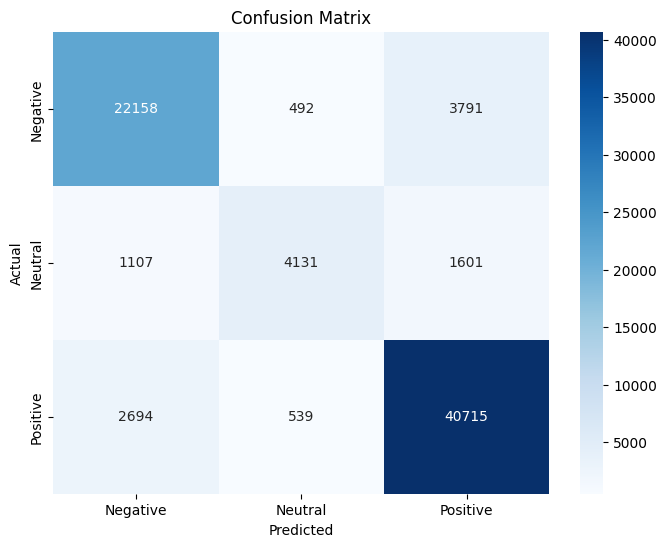

In [ ]:
# Confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm_optimized)

plt.figure(figsize=(8,6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', xticklabels=["Negative", "Neutral", "Positive"], yticklabels=["Negative", "Neutral", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig('SVM_optimized_cm_heatmap.png')
plt.show()

### Classifier comparison

| Classifier | F1 macro | F1 weighted | Class 0 recall score | Class 0 F1 score |
| ------ | ------ | ------ | ------ | ------ |
| XGBoost| 0.399 | 0.580 | 0.295 | 0.425 |
| Random Forest | 0.774 | 0.821 | 0.790 | 0.812 |
| Logistic Regression | 0.765 | 0.823 | 0.806 | 0.798 |
| SVM | 0.819 | 0.867 | 0.833 | 0.846 |
| Logistic Regression with hyperparameter tuning | 0.816 | 0.866 | 0.831 | 0.845 |
| SVM with hyperparameter tuning | 0.813 | 0.866 | 0.838 | 0.846 |
| Trainer Class twitter-roberta-base-sentiment-latest (notebook 3) | 0.820 | 0.895 | 0.901 | 0.896 |

- The hyperparameter tuning improved the performance of both models and both achived similar statistical metrics.

- The trainer class twitter-roberta-base-sentiment-latest from notebook `3.transformer_classification.ipynb` achieved the best performance out of all the classifiers.